# Step 3: Geo-intervention Generation

## Libaries

In [16]:
from pathlib import Path
from pickle import dump, load
from pprint import pprint

import modules as geoint
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Folders

Create folders for storing models and related data.

In [17]:
# Set folder for data and models
data_folder = '../../tmp/data'
model_folder = '../../tmp/models'
downloads_folder = '../../tmp/downloads'

# Create folders for model data
Path(data_folder).mkdir(parents=True, exist_ok=True)
Path(model_folder).mkdir(parents=True, exist_ok=True)

## Load Best Model

In [ ]:
# Load toronto boundaries for clipping
city = gpd.read_file(f'{downloads_folder}/toronto.geojson')\
    .to_crs(32617)

# Determine best model
scores = pd.read_csv(f'{model_folder}/scores.csv')
opt_model = scores[(scores.metric == 'mean_absolute_error')]\
    .sort_values('score')\
    .iloc[0]\
    .model
opt_model_label = opt_model\
    .replace('_10', ' (10x10)')\
    .replace('_40', ' (40x40)')\
    .replace('_80', ' (80x80)')

# Create dict for best model
models = {}
geodata = {}

# Determine size and model type based on name
model_type = opt_model.split('_')[0]
size = int(opt_model.split('_')[1])
    
# Load data
print(f'Processing geogrid_to_{size}...')
xraw = gpd.read_file(f'{data_folder}/geogrid_to_{size}.geojson')

# Clip data
xraw = xraw.clip(city)

# Drop geometry and set outcome var
x = pd.DataFrame(xraw.drop(columns='geometry'))
ycol = 'collisions_count'
geodata[f'geogrid_to_{size}'] = xraw
    
# Columns to remove from input data
startswith = ['collisions']

# Drop columns except target col
drop = [c for c in x.columns if any(c.startswith(s) for s in startswith) and c != ycol]
x = x.drop(columns=drop)
    
# Load autosklearn model
if model_type == 'autosklearn':
    ask_file = f'{model_folder}/autosklearn_{size}.pkl'
    print(f'Loading autosklearn_{size}...')
    with open(ask_file, 'rb') as f:
        ask = load(f)
    models[opt_model] = ask
    
# Load tpot model
if model_type == 'tpot':
    tpt_file = f'{model_folder}/tpot_{size}.pkl'
    print(f'Loading tpot_{size}...')
    tpt = geoint.models.AutoMLModel('TPOTRegressor')
    with open(tpt_file, 'rb') as f:
        tpt.model = load(f)
    tpt.last_x = x.drop(columns=ycol).select_dtypes('number').fillna(0)
    tpt.last_y = x[ycol]
    tpt.predict()
    models[opt_model] = tpt

print('Done!')

Processing geogrid_to_80...


## Optimization

In [15]:
# Determine top three infra vars
importances = pd.read_csv(f'{model_folder}/importances.csv')
importances_vars = importances[~importances.variable.str.startswith(('traffic', 'centrelines', 'crime'))]\
    .sort_values('importance_mean', ascending = False)\
    .head(3)\
    .variable\
    .tolist()

# Determine top traffic var
importances_traffic = importances[
    importances.variable.str.startswith(('traffic')) &
    importances.variable.str.endswith(('sum'))
]\
    .sort_values('importance_mean', ascending = False)\
    .head(1)\
    .variable\
    .tolist()

# Create dict for storing opt results
opt_results = {
    'scenario': [],
    'original': [],
    'optimized': [],
    'model': []
}

# Display traffic and infra vars
print(f'''
Traffic Variable
----------------
{importances_traffic[0]}
      
Top Three Infrastructure Variables
----------------------------------
1. {importances_vars[0]}
2. {importances_vars[1]}
3. {importances_vars[2]}
''')


Traffic Variable
----------------
traffic_eb_cars_l_sum
      
Top Three Infrastructure Variables
----------------------------------
1. red_light_cams_count
2. transit_shelters_count
3. wayfind_count



### Scenario 1

Create geo-interventions by optimizing top three infrastructure variables with higher than average traffic.

In [5]:
# Define local constraints
lconstr1 = {
    'transit_shelters_count': {'query': 'traffic_wb_car_r_sum >= traffic_wb_car_r_sum.mean()'},
    'fire_hydrants_count': {'query': 'traffic_wb_car_r_sum >= traffic_wb_car_r_sum.mean()'},
    'red_light_cams_count': {'query': 'traffic_wb_car_r_sum >= traffic_wb_car_r_sum.mean()'},
}

# Create optimizer
print(f'Optimizing predictions for {opt_model}...')
opt1_file = f'{model_folder}/{opt_model}_opt1.pkl'
if Path(opt1_file).is_file():
    
    # Load optimizer from saved file
    print(f'Optimizer for {opt_model} exists - loading results...')
    with open(opt1_file, 'rb') as f:
        opt1_results = load(f)
else:
    
    # Run optimizer
    print(f'Running optimization for {opt_model}...')
    opt1 = geoint.optimization.Optimizer(models[opt_model], lconstr1, 'BayesianOptimization', verbose=0, ymax=False)
    opt1.optimize(n_iter=100)
    
    # Save results
    print(f'Saving optimization for {opt_model}...')
    opt1_results = {
        'original': [sum(opt1.model.last_y)],
        'optimized': [opt1.optimal_y],
        'optimal': opt1.optimal,
        'optimal_params': opt1.optimal_params,
        'optimal_details': opt1.optimal_details,
        'params': opt1.optimizer_params
    }
    with open(opt1_file, 'wb') as f:
        dump(opt1_results, f)
        
# Store opt results
opt_results['scenario'] += ['Scenario 1: Higher than avg westbound car traffic']
opt_results['original'] += opt1_results['original']
opt_results['optimized'] += opt1_results['optimized']
opt_results['model'] += [opt_model]
print('Done!')

Optimizing predictions for tpot_80...
Optimizer for tpot_80 exists - loading results...
Done!


### Scenario 2

Create geo-interventions by optimizing  top three infrastructure variables with lower than average numbers.

In [6]:
# Define local constraints
lconstr2 = {
    'transit_shelters_count': {'query': 'transit_shelters_count < transit_shelters_count.mean()'},
    'fire_hydrants_count': {'query': 'fire_hydrants_count < fire_hydrants_count.mean()'},
    'red_light_cams_count': {'query': 'red_light_cams_count < red_light_cams_count.mean()'},
}

# Create optimizer
print(f'Optimizing predictions for {opt_model}...')
opt2_file = f'{model_folder}/{opt_model}_opt2.pkl'
if Path(opt2_file).is_file():
    
    # Load optimizer from saved file
    print(f'Optimizer for {opt_model} exists - loading results...')
    with open(opt2_file, 'rb') as f:
        opt2_results = load(f)
else:
    
    # Run optimizer
    print(f'Running optimization for {opt_model}...')
    opt2 = geoint.optimization.Optimizer(models[opt_model], lconstr2, 'BayesianOptimization', verbose=0, ymax=False)
    opt2.optimize(n_iter=100)
    
    # Save results
    print(f'Saving optimization for {opt_model}...')
    opt2_results = {
        'original': [sum(opt2.model.last_y)],
        'optimized': [opt2.optimal_y],
        'optimal': opt2.optimal,
        'optimal_params': opt2.optimal_params,
        'optimal_details': opt2.optimal_details,
        'params': opt2.optimizer_params
    }
    with open(opt2_file, 'wb') as f:
        dump(opt2_results, f)
        
# Store opt results
opt_results['scenario'] += ['Scenario 2: Modify scarce intervention cells']
opt_results['original'] += opt2_results['original']
opt_results['optimized'] += opt2_results['optimized']
opt_results['model'] += [opt_model]
print('Done!')

Optimizing predictions for tpot_80...
Optimizer for tpot_80 exists - loading results...
Done!


### Optimization Results

In [7]:
opt_results = pd.DataFrame(opt_results)
opt_results['diff'] = opt_results.optimized - opt_results.original
opt_results

,scenario,original,optimized,model,diff
0,Scenario 1: Higher than avg northbound truck t...,588876.0,428374.456131,tpot_80,-160501.543869
1,Scenario 2: Modify scarce intervention cells,588876.0,362683.468054,tpot_80,-226192.531946


## Generated Geo-interventions

In [8]:
# Read data for selected model
gdata = geodata['geogrid_to_80'].copy()
gcols = [
    'transit_shelters_count',
    'childcare_igspace_mad',
    'fire_hydrants_count'
]

# Get optimal parameters
optimalp = {
    'opt1': opt1_results['optimal_params'],
    'opt2': opt2_results['optimal_params'],
}

# Get params used for optimization
opt_params = {
    'opt1': opt1_results['params'],
    'opt2': opt2_results['params']
}
for k in opt_params:
    opt_params[k].index.name = None
    
# Set params to optimal params
for k in opt_params:
    opt_params[k]['value_optimal'] = opt_params[k]['value_orig']
    opt_params[k].loc[optimalp[k].keys(), 'value_optimal'] = list(optimalp[k].values())

In [9]:
# Set data to optimal params
for k in opt_params:
    params = opt_params[k]
    for c in params.column.unique():
        p = params[params.column == c]
        oc = f'{c}_{k}'
        gdata[oc] = gdata[c].copy()
        gdata.loc[p.row, oc] = p.value_optimal.tolist()
        gdata[f'{oc}_diff'] = gdata[oc] - gdata[c]

In [10]:
gdata[[c + '_opt1' for c in gcols] + [ycol]].head(100)

,transit_shelters_count_opt1,red_light_cams_count_opt1,ambulance_count_opt1,wys_count_opt1,collisions_count
2446,0.0,0.0,0.0,0.0,0.0
2447,0.0,0.0,0.0,0.0,0.0
2569,0.0,0.0,0.0,0.0,2.0
2508,0.0,0.0,0.0,0.0,0.0
2509,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
1662,2.0,0.0,1.0,0.0,286.0
1541,6.0,0.0,0.0,1.0,188.0
1724,1.0,0.0,0.0,4.0,220.0
1663,4.0,0.0,0.0,3.0,164.0


### Optimization Parameters

In [11]:
opt_params['opt1']

,column,row,param,value,bounds,value_orig,value_optimal
transit_shelters_count_1534,transit_shelters_count,1534,transit_shelters_count_1534,24.538534,"(0.0, 27.0)",8.0,19.347208
transit_shelters_count_1474,transit_shelters_count,1474,transit_shelters_count_1474,2.786085,"(0.0, 27.0)",5.0,18.110058
transit_shelters_count_1352,transit_shelters_count,1352,transit_shelters_count_1352,14.291287,"(0.0, 27.0)",3.0,2.739589
transit_shelters_count_1781,transit_shelters_count,1781,transit_shelters_count_1781,12.481425,"(0.0, 27.0)",4.0,12.671688
transit_shelters_count_1538,transit_shelters_count,1538,transit_shelters_count_1538,10.092127,"(0.0, 27.0)",0.0,24.122149
...,...,...,...,...,...,...,...
wys_count_3711,wys_count,3711,wys_count_3711,0.502440,"(0.0, 9.0)",0.0,7.573580
wys_count_3712,wys_count,3712,wys_count_3712,1.987067,"(0.0, 9.0)",0.0,6.770651
wys_count_3713,wys_count,3713,wys_count_3713,3.098313,"(0.0, 9.0)",0.0,3.221597
wys_count_3468,wys_count,3468,wys_count_3468,3.337667,"(0.0, 9.0)",0.0,2.603803


In [12]:
len(opt_params['opt1'].index)

2716

In [13]:
opt_params['opt2']

,column,row,param,value,bounds,value_orig,value_optimal
transit_shelters_count_2446,transit_shelters_count,2446,transit_shelters_count_2446,6.784072,"(0.0, 27.0)",0.0,1.939086
transit_shelters_count_2447,transit_shelters_count,2447,transit_shelters_count_2447,24.607976,"(0.0, 27.0)",0.0,16.310051
transit_shelters_count_2569,transit_shelters_count,2569,transit_shelters_count_2569,10.008189,"(0.0, 27.0)",0.0,3.882069
transit_shelters_count_2508,transit_shelters_count,2508,transit_shelters_count_2508,26.793318,"(0.0, 27.0)",0.0,18.673106
transit_shelters_count_2509,transit_shelters_count,2509,transit_shelters_count_2509,24.948560,"(0.0, 27.0)",0.0,23.079648
...,...,...,...,...,...,...,...
wys_count_4510,wys_count,4510,wys_count_4510,0.479679,"(0.0, 9.0)",0.0,3.595259
wys_count_4449,wys_count,4449,wys_count_4449,4.066740,"(0.0, 9.0)",0.0,7.067444
wys_count_4450,wys_count,4450,wys_count_4450,2.080157,"(0.0, 9.0)",0.0,0.402283
wys_count_4389,wys_count,4389,wys_count_4389,7.852763,"(0.0, 9.0)",0.0,7.406204


In [14]:
len(opt_params['opt2'].index)

8186

### Geo-intervention Maps

Scenario 1

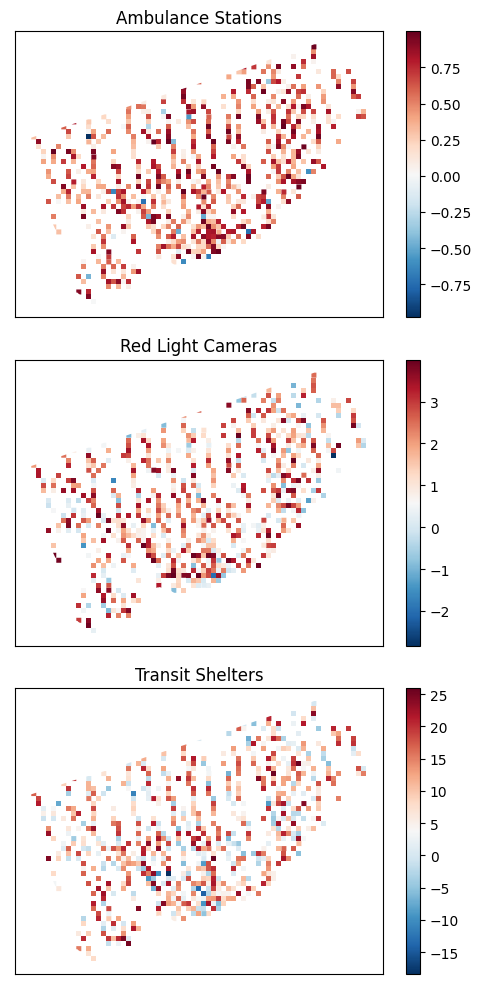

In [ ]:
fig = plt.figure()
fig.set_size_inches(5, 10)
pdata = gdata.copy()
pdata.replace(0, np.nan, inplace=True)

# Transit shelters
ax = plt.subplot(3, 1, 1) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='transit_shelters_count_opt1_diff', legend=True)
ax.set_title('Transit Shelters')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

# Childcare
ax = plt.subplot(3, 1, 2) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='childcare_gspace_mad_opt1_diff', legend=True)
ax.set_title('Licensed Child Care Centres')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

# Fire Hydrants
ax = plt.subplot(3, 1, 3) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='fire_hydrants_count_opt1_diff', legend=True)
ax.set_title('Fire Hydrants')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

Scenario 2

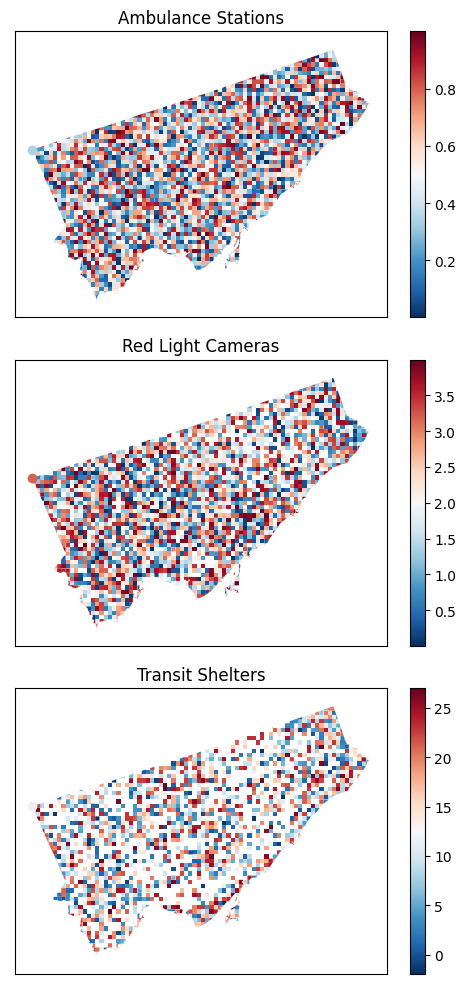

In [ ]:
fig = plt.figure()
fig.set_size_inches(5, 10)
pdata = gdata.copy()
pdata.replace(0, np.nan, inplace=True)

# Transit shelters
ax = plt.subplot(3, 1, 1) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='transit_shelters_count_opt2_diff', legend=True)
ax.set_title('Transit Shelters')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

# Transit shelters
ax = plt.subplot(3, 1, 2) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='fire_hydrants_count_opt2_diff', legend=True)
ax.set_title('Fire Hydrants')
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

# Red light cams
ax = plt.subplot(3, 1, 3) # nrows, ncols, axes position
pdata.plot(ax=ax, cmap='RdBu_r', column='red_light_cams_count_opt2_diff', legend=True)
ax.set_title('Red Light Cameras ') # + pdata.red_light_cams_count_opt2_diff.sum()
ax.set_aspect('equal', adjustable='datalim')
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()